1. IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize

2. DATA EXPLORATION

Image Data (MNIST)

Shape: (60000, 28, 28)
Mean: 33.318421449829934
Std: 78.56748998339798


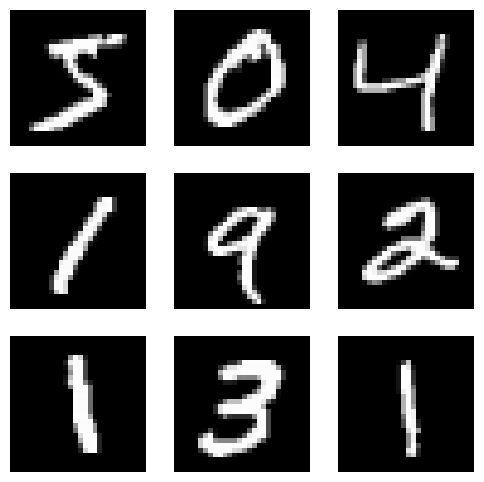

MNIST Missing: 0


In [5]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Shape:", x_train.shape)
print("Mean:", np.mean(x_train))
print("Std:", np.std(x_train))

# Show sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

# Missing values check
print("MNIST Missing:", np.isnan(x_train).sum())

breast cancer(TABULAR)

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

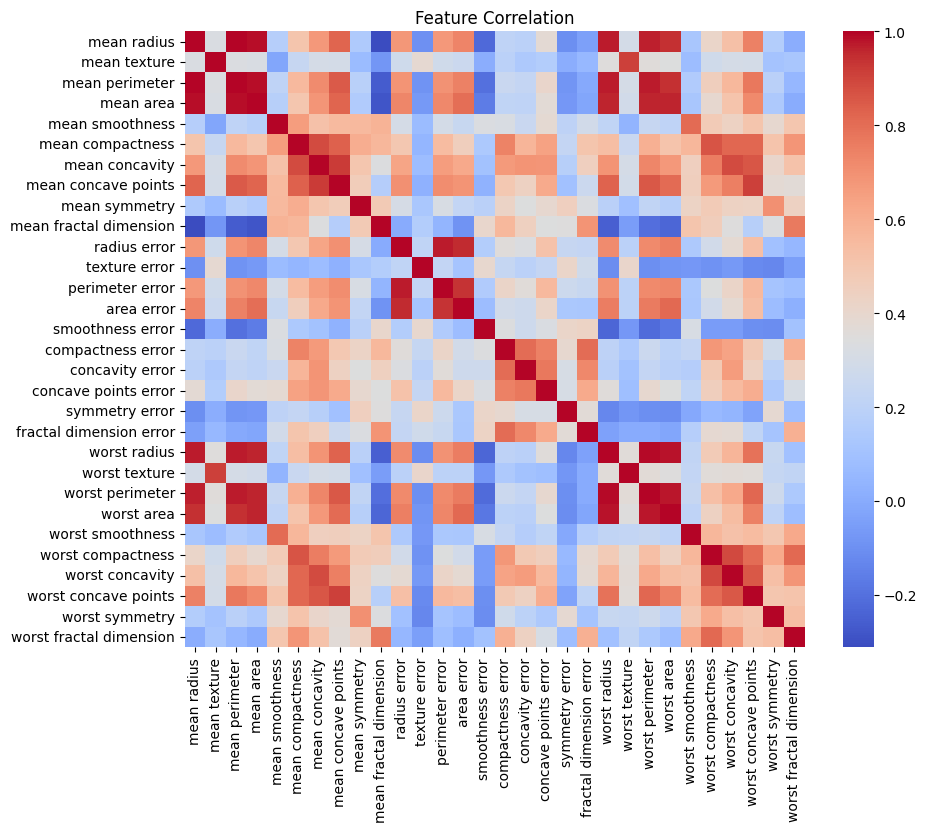

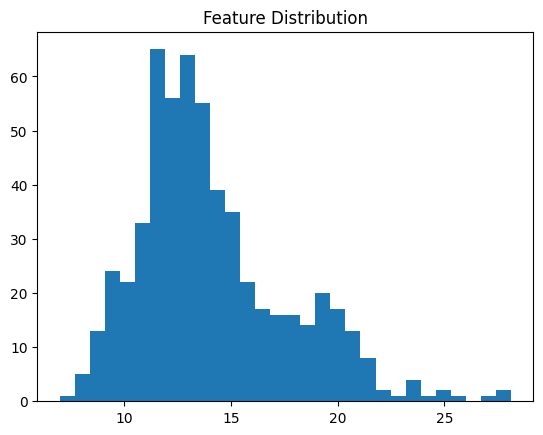

Missing Values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [6]:
# Load Breast Cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Statistics
print(df.describe())

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Histogram
plt.hist(df.iloc[:,0], bins=30)
plt.title("Feature Distribution")
plt.show()

# Missing values
print("Missing Values:\n", df.isnull().sum())

3. DATA PREPARATION

Image

In [8]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

Tabular

In [9]:
# Scale tabular data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Split tabular data
X_train, X_temp = train_test_split(df_scaled, test_size=0.4, random_state=42)
X_val, X_test_tab = train_test_split(X_temp, test_size=0.5, random_state=42)

4. BASIC AUTOENCODER

In [10]:
input_dim = 784
latent_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
latent = Dense(latent_dim, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(latent)
output = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output)

autoencoder.compile(optimizer='adam', loss='mse')

history_ae = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0594 - val_loss: 0.0322
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0255 - val_loss: 0.0202
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0183 - val_loss: 0.0159
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - val_loss: 0.0141
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0139 - val_loss: 0.0129
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0130 - val_loss: 0.0123
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0124 - val_loss: 0.0117
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0113
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0111 - val_loss: 0.0107


5. DENOISING AUTOENCODER

In [11]:
noise_factor = 0.3

x_train_noisy = x_train_flat + noise_factor * np.random.normal(size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(size=x_test_flat.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

dae = Model(input_layer, output)
dae.compile(optimizer='adam', loss='mse')

history_dae = dae.fit(
    x_train_noisy, x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0161 - val_loss: 0.0148
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0148 - val_loss: 0.0141
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143 - val_loss: 0.0141
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0141 - val_loss: 0.0137
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0139 - val_loss: 0.0136
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0138 - val_loss: 0.0135
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0136 - val_loss: 0.0133
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0135 - val_loss: 0.0133
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134 - val_loss: 0.0132
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0133 - val_loss: 0.0131


6. SPARSE AUTOENCODER

In [12]:
latent_sparse = Dense(32, activation='relu',
                      activity_regularizer=regularizers.l1(1e-5))(encoded)

decoded_sparse = Dense(128, activation='relu')(latent_sparse)
output_sparse = Dense(784, activation='sigmoid')(decoded_sparse)

sae = Model(input_layer, output_sparse)

sae.compile(optimizer='adam', loss='mse')

history_sae = sae.fit(
    x_train_flat, x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0944 - val_loss: 0.0720
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0673 - val_loss: 0.0633
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0624 - val_loss: 0.0616
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0614 - val_loss: 0.0611
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0608 - val_loss: 0.0607
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0591 - val_loss: 0.0571
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0572 - val_loss: 0.0563
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0565 - val_loss: 0.0559
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0560 - val_loss: 0.0582
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0550 - val_loss: 0.0535


7. HYPERPARAMETER TUNING (Latent Dim)

Training with latent_dim = 16
Training with latent_dim = 32
Training with latent_dim = 64
Results: {16: 0.016492139548063278, 32: 0.010544917546212673, 64: 0.007770114112645388}


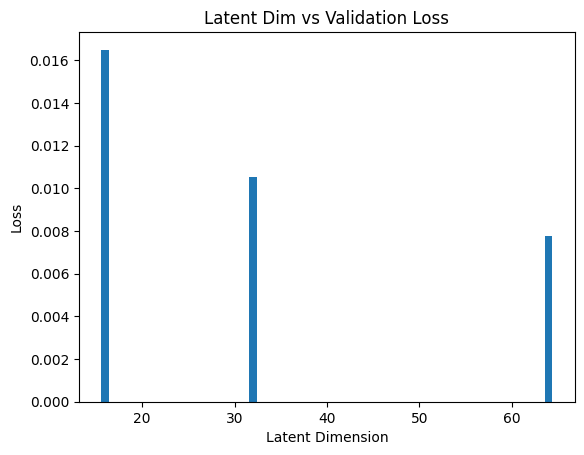

In [13]:
latent_dims = [16, 32, 64]
results = {}

for ld in latent_dims:
    print(f"Training with latent_dim = {ld}")

    input_layer = Input(shape=(784,))
    encoded = Dense(128, activation='relu')(input_layer)
    latent = Dense(ld, activation='relu')(encoded)

    decoded = Dense(128, activation='relu')(latent)
    output = Dense(784, activation='sigmoid')(decoded)

    model = Model(input_layer, output)
    model.compile(optimizer=Adam(0.001), loss='mse')

    history = model.fit(
        x_train_flat, x_train_flat,
        epochs=10,
        batch_size=256,
        validation_data=(x_test_flat, x_test_flat),
        verbose=0
    )

    results[ld] = history.history['val_loss'][-1]

print("Results:", results)

# Plot
plt.bar(results.keys(), results.values())
plt.title("Latent Dim vs Validation Loss")
plt.xlabel("Latent Dimension")
plt.ylabel("Loss")
plt.show()

8. HYPERPARAMETER (NOISE TEST - DAE)

In [14]:
noise_levels = [0.1, 0.3, 0.5]

for noise in noise_levels:
    print(f"Testing noise = {noise}")

    x_train_noisy = x_train_flat + noise * np.random.normal(size=x_train_flat.shape)
    x_train_noisy = np.clip(x_train_noisy, 0., 1.)

    dae.fit(x_train_noisy, x_train_flat, epochs=5, batch_size=256, verbose=0)

Testing noise = 0.1
Testing noise = 0.3
Testing noise = 0.5


9. HYPERPARAMETER (SPARSE λ)

In [15]:
lambdas = [1e-4, 1e-5, 1e-6]

for l in lambdas:
    print(f"Testing lambda = {l}")

    latent_sparse = Dense(32, activation='relu',
                          activity_regularizer=regularizers.l1(l))(encoded)

Testing lambda = 0.0001
Testing lambda = 1e-05
Testing lambda = 1e-06


10. RECONSTRUCTION + MSE

In [16]:
# Predictions
ae_recon = autoencoder.predict(x_test_flat)
dae_recon = dae.predict(x_test_flat)
sae_recon = sae.predict(x_test_flat)

# MSE
mse_ae = mean_squared_error(x_test_flat, ae_recon)
mse_dae = mean_squared_error(x_test_flat, dae_recon)
mse_sae = mean_squared_error(x_test_flat, sae_recon)

print("AE MSE:", mse_ae)
print("DAE MSE:", mse_dae)
print("SAE MSE:", mse_sae)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AE MSE: 0.01552925623089819
DAE MSE: 0.01552925623089819
SAE MSE: 0.06916379666551632


11. RECONSTRUCTION IMAGES

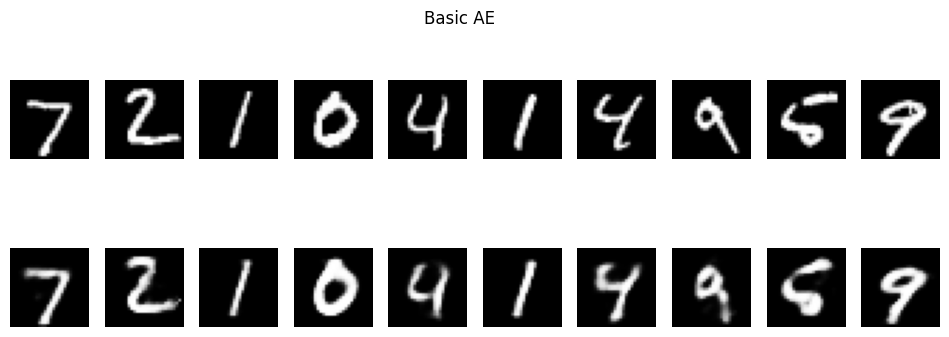

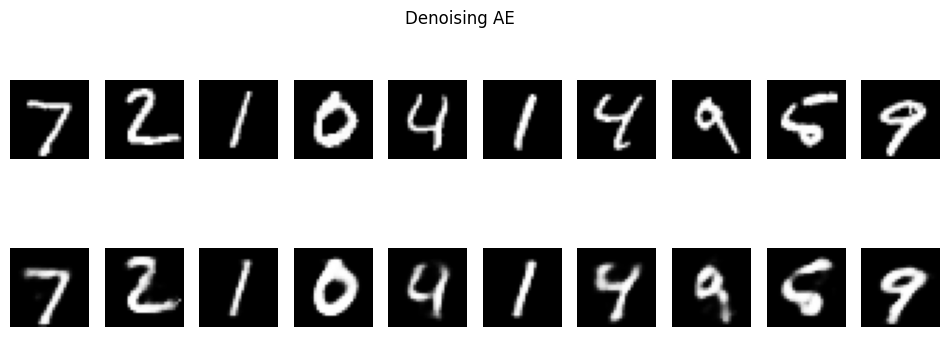

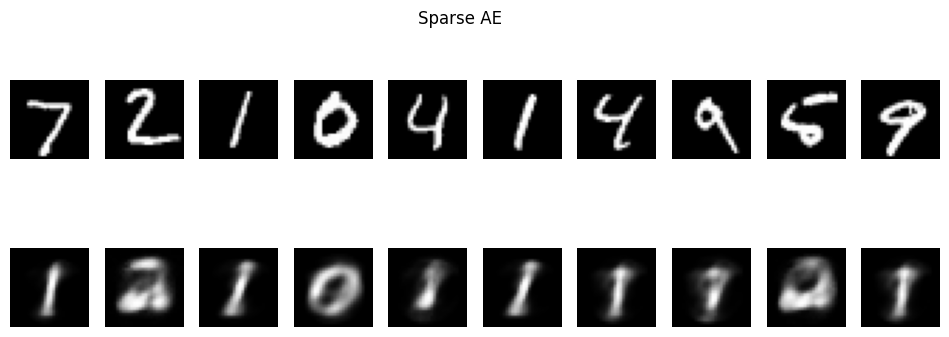

In [17]:
def plot_reconstruction(original, reconstructed, title):
    plt.figure(figsize=(12,4))

    for i in range(10):
        plt.subplot(2,10,i+1)
        plt.imshow(original[i].reshape(28,28), cmap='gray')
        plt.axis('off')

        plt.subplot(2,10,i+11)
        plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

plot_reconstruction(x_test_flat, ae_recon, "Basic AE")
plot_reconstruction(x_test_flat, dae_recon, "Denoising AE")
plot_reconstruction(x_test_flat, sae_recon, "Sparse AE")

12. DOWNSTREAM TASK

In [19]:
# Encoder
encoder = Model(input_layer, latent)

latent_train = encoder.predict(x_train_flat)
latent_test = encoder.predict(x_test_flat)

#  TAKE SMALL DATA (IMPORTANT)
latent_train_small = latent_train[:10000]
y_train_small = y_train[:10000]

latent_test_small = latent_test[:2000]
y_test_small = y_test[:2000]

# Model (FAST)
clf = LogisticRegression(max_iter=500)

clf.fit(latent_train_small, y_train_small)

pred = clf.predict(latent_test_small)

# Results
print("Accuracy:", accuracy_score(y_test_small, pred))
print("Precision:", precision_score(y_test_small, pred, average='macro'))
print("Recall:", recall_score(y_test_small, pred, average='macro'))
print("F1:", f1_score(y_test_small, pred, average='macro'))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.878
Precision: 0.8761720722765787
Recall: 0.8769049931062055
F1: 0.8762611166511052


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


13. ROC-AUC

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=range(10))
probs = clf.predict_proba(latent_test)

roc = roc_auc_score(y_test_bin, probs, multi_class='ovr')
print("ROC-AUC:", roc)

ROC-AUC: 0.9916821611424341


14. LATENT SPACE VISUALIZATION

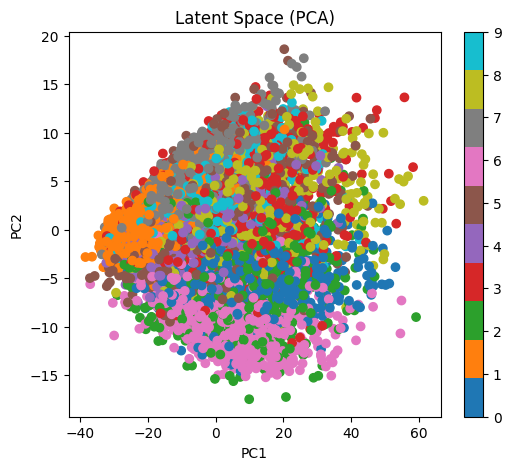

In [21]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_test)

plt.figure(figsize=(6,5))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=y_test, cmap='tab10')
plt.colorbar(scatter)
plt.title("Latent Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

15. MODEL COMPARISON GRAPH

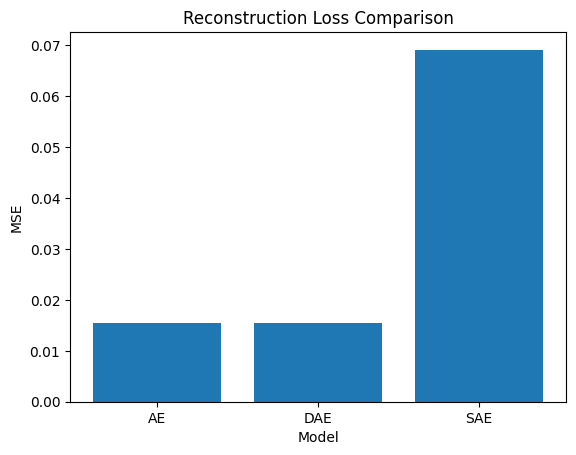

In [22]:
models = ['AE', 'DAE', 'SAE']
mse_values = [mse_ae, mse_dae, mse_sae]

plt.bar(models, mse_values)
plt.title("Reconstruction Loss Comparison")
plt.ylabel("MSE")
plt.xlabel("Model")
plt.show()

16. TRAINING CURVES

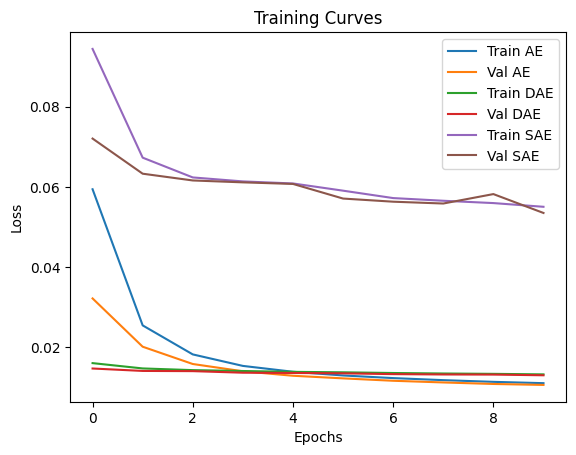

In [23]:
plt.plot(history_ae.history['loss'], label='Train AE')
plt.plot(history_ae.history['val_loss'], label='Val AE')

plt.plot(history_dae.history['loss'], label='Train DAE')
plt.plot(history_dae.history['val_loss'], label='Val DAE')

plt.plot(history_sae.history['loss'], label='Train SAE')
plt.plot(history_sae.history['val_loss'], label='Val SAE')

plt.legend()
plt.title("Training Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()